# **Federal Clean Energy Analysis Capstone Project**

Author: Julia Mei Hanzl

Date: March 2026

## Environmental Research Question: 

- Does federal support push forward the clean energy transition across US states?
- Does each federal policy have same influence for the creation of state clean energy laws in the US?

Link to GitHub repository: \[[https://github.com/juliahanzl/US\_Renewable\_Energy\_EDS\_Capstone](https://github.com/juliahanzl/US_Renewable_Energy_EDS_Capstone) \]



# **Background**

Currently the earth’s temperature has been raising significantly throughout its seasonal cycles \- these extreme temperature increase has been linked with degrading human health, damaging ecosystems and increase natural disasters \(heatwaves, droughts, wildfires, and floods, etc

In 2022, the US primary energy consumption was about 16% of total world primary energy consumption ~ 600 QBtu. 

In 2026, US federal government is pulling back their support for clean energy sources and endorsing fossil fuel energy generation

In the past the federal government has created laws/acts to show their support of the clean energy transition. These goals set by the federal government must be met and the funding given to states by the federal government allows individual states to decide how to contribute to clean energy in their communities.

States have relied on this federal funding to create more opportunities for citizen to participate in the clean energy transition through laws and regulations, provide programs and incentives.

By determining if the past energy laws the federal government has a significant effect on the creation of clean energy laws, this could inspire people to take a step back to see what they can control and how they can organize in their communities to promote accessible clean energy to citizens to increase health, safety and environmental impacts.



--------------



## Loading Data

Relevant Lectures:
<br>**Course 1, Module 1**: "Getting to know Environmental Data" by Eli — Covers types and sources of data.</br>
<br>**Course 2, Module 5**: "Sources of Environmental Data" by Jess O'Toole — Discusses where to find free/accessible data sources.</br>



In [3]:
#find current working directory
getwd()

#set current working directory
setwd("/home/user/Capstone_March_2026/US_Renewable_Energy_EDS_Capstone")
getwd()

[1] "/home/user/Capstone_March_2026/US_Renewable_Energy_EDS_Capstone/2.scripts"

[1] "/home/user/Capstone_March_2026/US_Renewable_Energy_EDS_Capstone"

In [108]:
#load packages
library(tidyverse)
library(lubridate) #for date formatting
library(ggnewscale) #create a second color scale
library(patchwork) #for visual stacking
library(ggpubr) #for plots
library(PairedData) #for paired boxplots

In [86]:
#load dataset
state_acts <- read.csv('/home/user/Capstone_March_2026/US_Renewable_Energy_EDS_Capstone/1.raw_data/state_laws_and_incentives.csv')

#look at data
glimpse(state_acts)
colnames(state_acts)
unique(state_acts$Type)

Rows: 831
Columns: 22
$ Law.Id                  <int> 274, 276, 305, 309, 319, 321, 342, 348, 349, 3…
$ State                   <chr> "US", "US", "US", "US", "US", "US", "US", "US"…
$ Title                   <chr> "Air Pollution Control Program", "Clean Fuel F…
$ Text                    <chr> "The Air Pollution Control Program assists sta…
$ Enacted.Date            <chr> "", "", "1990-11-15 00:00:00 UTC", "2005-08-10…
$ Amended.Date            <chr> "", "", "", "", "2022-08-16 00:00:00 UTC", "",…
$ Recent.                 <chr> "false", "false", "false", "false", "false", "…
$ Sequence.Number         <int> 36, 35, 38, 55, 11, 20, 16, 12, 12, 16, 14, 51…
$ Type                    <chr> "Programs", "Programs", "Laws and Regulations"…
$ Agency                  <chr> "U.S. Environmental Protection Agency", "U.S. …
$ Significant.Update.Date <chr> "", "", "", "", "2022-08-24 14:14:15 UTC", "",…
$ Expired.Date            <chr> "", "", "", "", "2025-01-01 00:00:00 UTC", "20…
$ Archived.Date   

[1] "Law.Id"                  "State"                  
 [3] "Title"                   "Text"                   
 [5] "Enacted.Date"            "Amended.Date"           
 [7] "Recent."                 "Sequence.Number"        
 [9] "Type"                    "Agency"                 
[11] "Significant.Update.Date" "Expired.Date"           
[13] "Archived.Date"           "Repealed.Date"          
[15] "Topic"                   "Technology.Categories"  
[17] "Incentive.Categories"    "Regulation.Categories"  
[19] "User.Categories"         "References"             
[21] "Status"                  "Status.Date"

[1] "Programs"                "Laws and Regulations"   
[3] "Incentives"              "State Incentives"       
[5] "State Hybrid Incentives"

## Cleaning Data

Relevant Lectures:
<br>**Course 3, Module 10**: "Data Cleaning Pt. 1" and "Data Cleaning Pt. 2" by JRS — Introduces key principles and practical data-cleaning techniques in R.</br>
<br>**Course 3, Module 8**: "Using EDA to Clean Data" by Angel — Discusses identifying common issues in data and addressing them.</br>



In [87]:
clean_state_acts <- state_acts %>%
    dplyr::select(State, Title, Text, Enacted.Date, Type, Repealed.Date) %>% #what variables do I want - #too many packages with the same functions
    filter(Type == "Laws and Regulations") %>% #only want Laws and Regulations
    filter(Enacted.Date != "") %>% 

    #want Enacted Year only
    mutate(Enacted.Date = ymd_hms(Enacted.Date)) %>% #date includes time and a timezone - use ymd_hms()
    mutate(Enacted.Year = year(Enacted.Date)) %>%

    #sort by year and then state
    dplyr::select(Enacted.Year, State, Title, Text) %>% #too many packages with the same functions
    arrange(Enacted.Year, State) %>%

    #separate out US (all states) and DC data
    filter(State != "US" & State != "DC")

head(clean_state_acts)

,Enacted.Year,State,Title,Text
,<dbl>,<chr>,<chr>,<chr>
1,1996,MA,State Agency Alternative Fuel Vehicle (AFV) Acquisition Requirement,"State fleets must acquire AFVs according to the requirements of the Energy Policy Act (EPAct) of 1992 and the Massachusetts Office of Vehicle Management (OVM) must approve any light-duty vehicle acquisition. All agencies must purchase the most economical, fuel-efficient, and low emission vehicles appropriate to their mission. OVM, in collaboration with the Massachusetts Department of Energy Resources, will set new minimum standards for vehicle mileage and work with agencies to acquire vehicles that provide the best value for the Commonwealth on a total cost of ownership basis. (Reference Executive Order 388, 1996, and Massachusetts Executive Office of Administration and Finance Administrative Bulletin 10, 2010)"
2,2000,IA,State Fleet Biofuels Use and Fuel Efficiency,"As part of the Green Government Initiative, the Iowa Office of Energy Independence (OEI), Department of Administrative Services, Department of Natural Resources, and Department of Transportation lead a Biofuels Task Force. This group focuses on issues including increasing each state agency's use of biofuels to the maximum amount feasible and increasing the fuel efficiency of the state's vehicle fleet. The Biofuels Task Force sets specific five- and ten-year targets related to these areas, which are included in the Green Government Master Plan. Progress toward these goals will be tracked using a reporting system developed under the Green Government Initiative, and resulting data will be made public via the OEI whenever possible. (Reference Executive Order 6, 2008)"
3,2001,MD,Alternative Fuel Vehicle (AFV) Acquisition Requirements,"Maryland established an AFV goal under the plan for \'Sustaining Maryland\'s Future with Clean Power, Green Buildings and Energy Efficiency.\' The state will revise fleet policy and purchasing guidelines to offer more flexibility in purchasing, where practical, low emission vehicles and AFVs for its fleet. The state must ensure that an average of 50% of the fuel used to operate bi-fuel and flexible fuel vehicles are alternative fuel. The state must also help develop the refueling and maintenance infrastructure required to make using certain types of AFV use practical. The state may provide technical assistance and other incentives to use clean technology, where practical, in state transit fleets. (Reference [Executive Order](https://governor.maryland.gov/category/executive-orders/) 01.01.2001.02)"
4,2001,NY,Alternative Fuel Vehicle (AFV) Acquisition Requirements,"All new light-duty vehicles that state agencies and other affected entities procure must be AFVs, with the exception of designated specialty, police, or emergency vehicles. Hybrid electric vehicles qualify under these requirements. State agencies and other affected entities that operate medium- and heavy-duty vehicles must implement strategies to reduce petroleum consumption and emissions by using alternative fuels and improving vehicle fleet fuel efficiency. State agencies and other affected entities may substitute the use of 450 gallons of 100% biodiesel (B100) for the acquisition of one AFV. Alternatively, using 2,250 gallons of biodiesel blends of 20% (B20) or 9,000 gallons of biodiesel blends of 5% (B5) may also be substituted in place of purchasing one AFV. No more than 50% of a given state agency fleet's AFV purchase requirement may be met by substituting B100, B20, or B5. (Reference Executive Order 111, 2001; Executive Order 142, 2005; and Executive Order 4, 2008)"
5,2001,SC,State Agency Alternative Fuel Use Requirement,"Whenever practical and economically feasible, all state agencies operating alternative fuel vehicles must use alternative fuels in those vehicles. Private businesses are encouraged to increase the use of alternative fuels in the state. (Reference Executive Order 2001-35)"
6,2002,IL,Corn-to-Ethanol Research Pilot Plant,"The

In [88]:
#look for missing data
table(clean_state_acts$State)
table(clean_state_acts$Enacted.Year) #missing years 1997 - 1999


AK AL AR AZ CA CO CT DE FL GA HI IA ID IL IN KS KY LA MA MD ME MI MN MO MS MT 
 3  4  3  8 15 10  2  2  8  1  8  3  3 17  4  1  5  9  9  4  6  7  9  1  3  3 
NC ND NE NH NJ NM NV NY OH OK OR PA RI SC SD TN TX UT VA VT WA WI WV WY 
 3  1  3  8  6  7  6  7  2 10 10  2  5  2  6  3  3  9  7 12 11  8  2  5 


1996 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 
   1    1    3    1    1    5    6   12   30   23   37   19   20   19   16    9 
2015 2016 2017 2018 2019 2020 2021 2022 
  13    4   26   13   15    1    2    9 

In [89]:
#group by year and state to find missing data for each state

state_stats <- clean_state_acts %>%
    
    #find total acts per state per year
    group_by(Enacted.Year, State) %>%
        mutate(Acts = n()) %>% #counts number of enacted laws each year
        distinct() %>%

        dplyr::select(State, Enacted.Year, Acts) %>%
        arrange (State, Enacted.Year) %>%
        distinct() %>% #there are missing years for each state
        
    #group by State make sure they all have data for years 1996 - 2022
    group_by(State) %>%
        complete(Enacted.Year = 1996:2022, fill = list(n = 0)) %>% #filling in missing years for each state
        mutate(Acts = replace_na(Acts, 0)) %>% #put number of acts with zerso for each missing year
        ungroup()
    
head(state_stats)

State,Enacted.Year,Acts
<chr>,<dbl>,<int>
AK,1996,0
AK,1997,0
AK,1998,0
AK,1999,0
AK,2000,0
AK,2001,0


In [90]:
#find total number of enacted state laws per year

year_state_stats <- state_stats %>%
  group_by(Enacted.Year) %>%
      summarize(Total_Acts = sum(Acts, na.rm = TRUE)) %>% 
      arrange(Enacted.Year) %>%
      ungroup() #for graphing

head(year_state_stats)

Enacted.Year,Total_Acts
<dbl>,<int>
1996,1
1997,0
1998,0
1999,0
2000,1
2001,3


## Exploratory Data Analysis (EDA)

Relevant Lectures:
<br>**Course 3, Module 9**: "Conducting Exploratory Data Analysis (EDA)" by JRS — Introduces how to explore relationships between variables and visualise data.</br>
<br>**Course 3, Module 10**: "Creating Data Visualizations for EDA" by JRS — Focuses on visualizing relationships between variables using linear regression and other plots.</br>



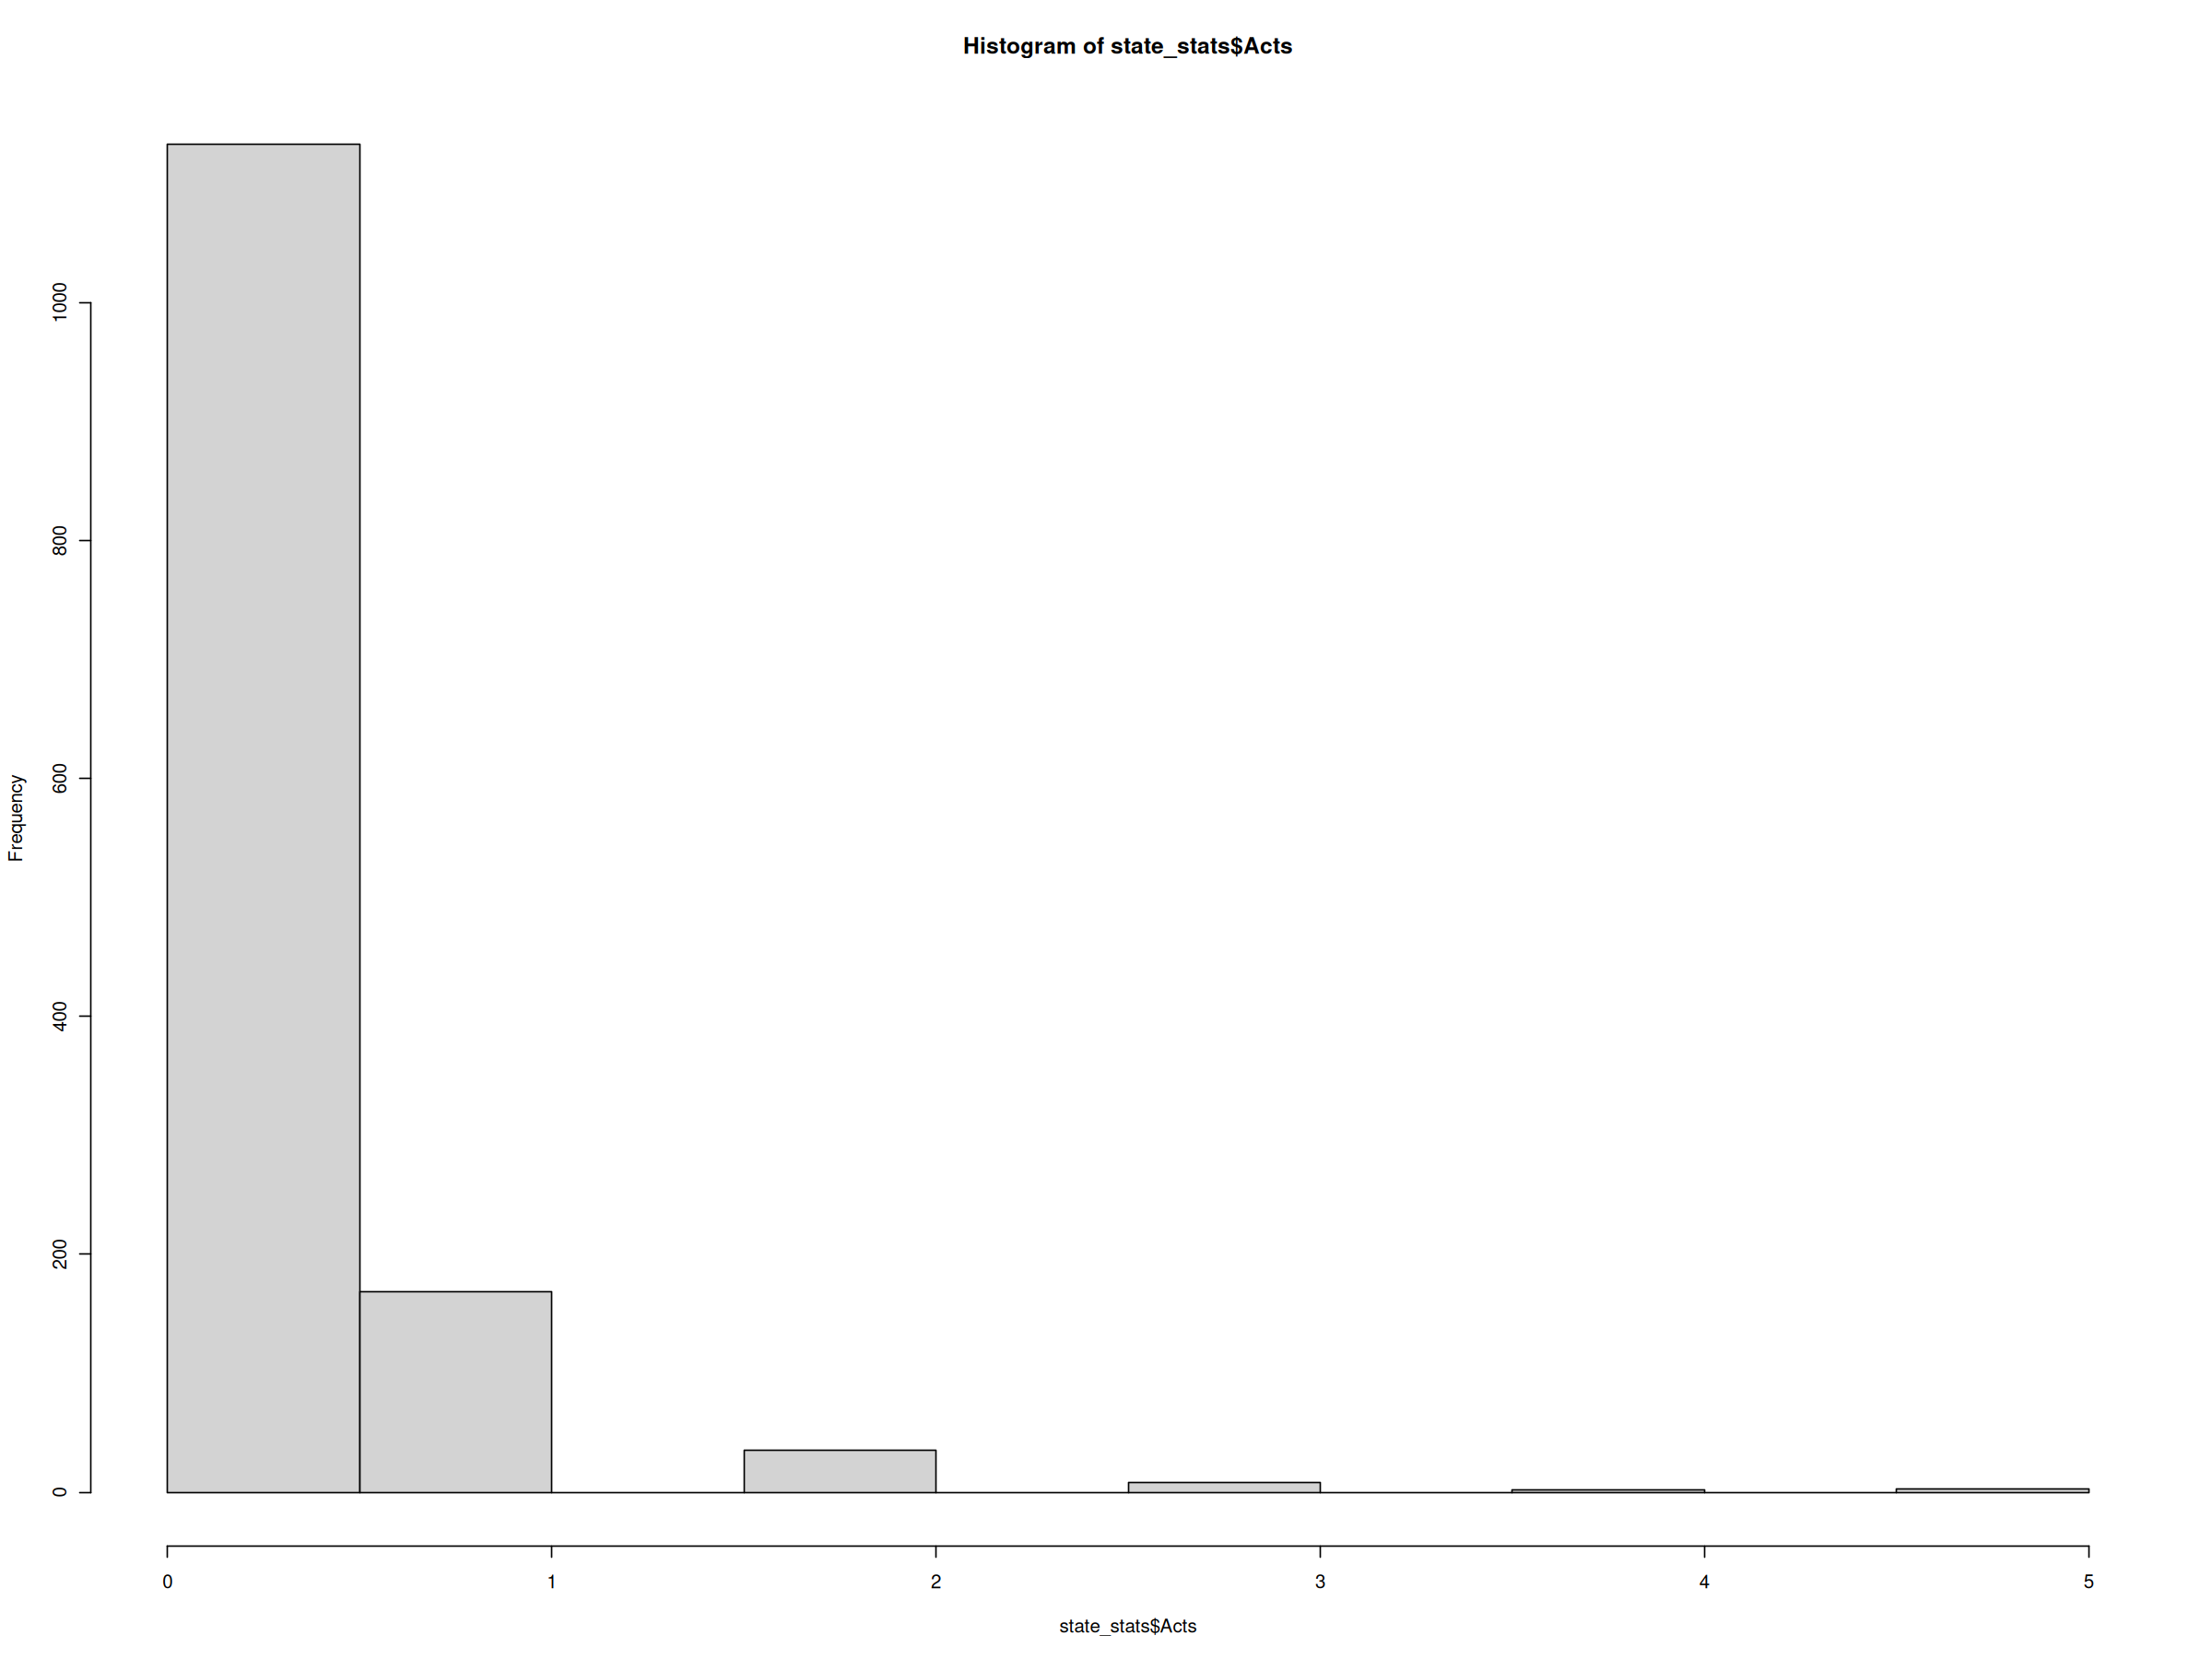

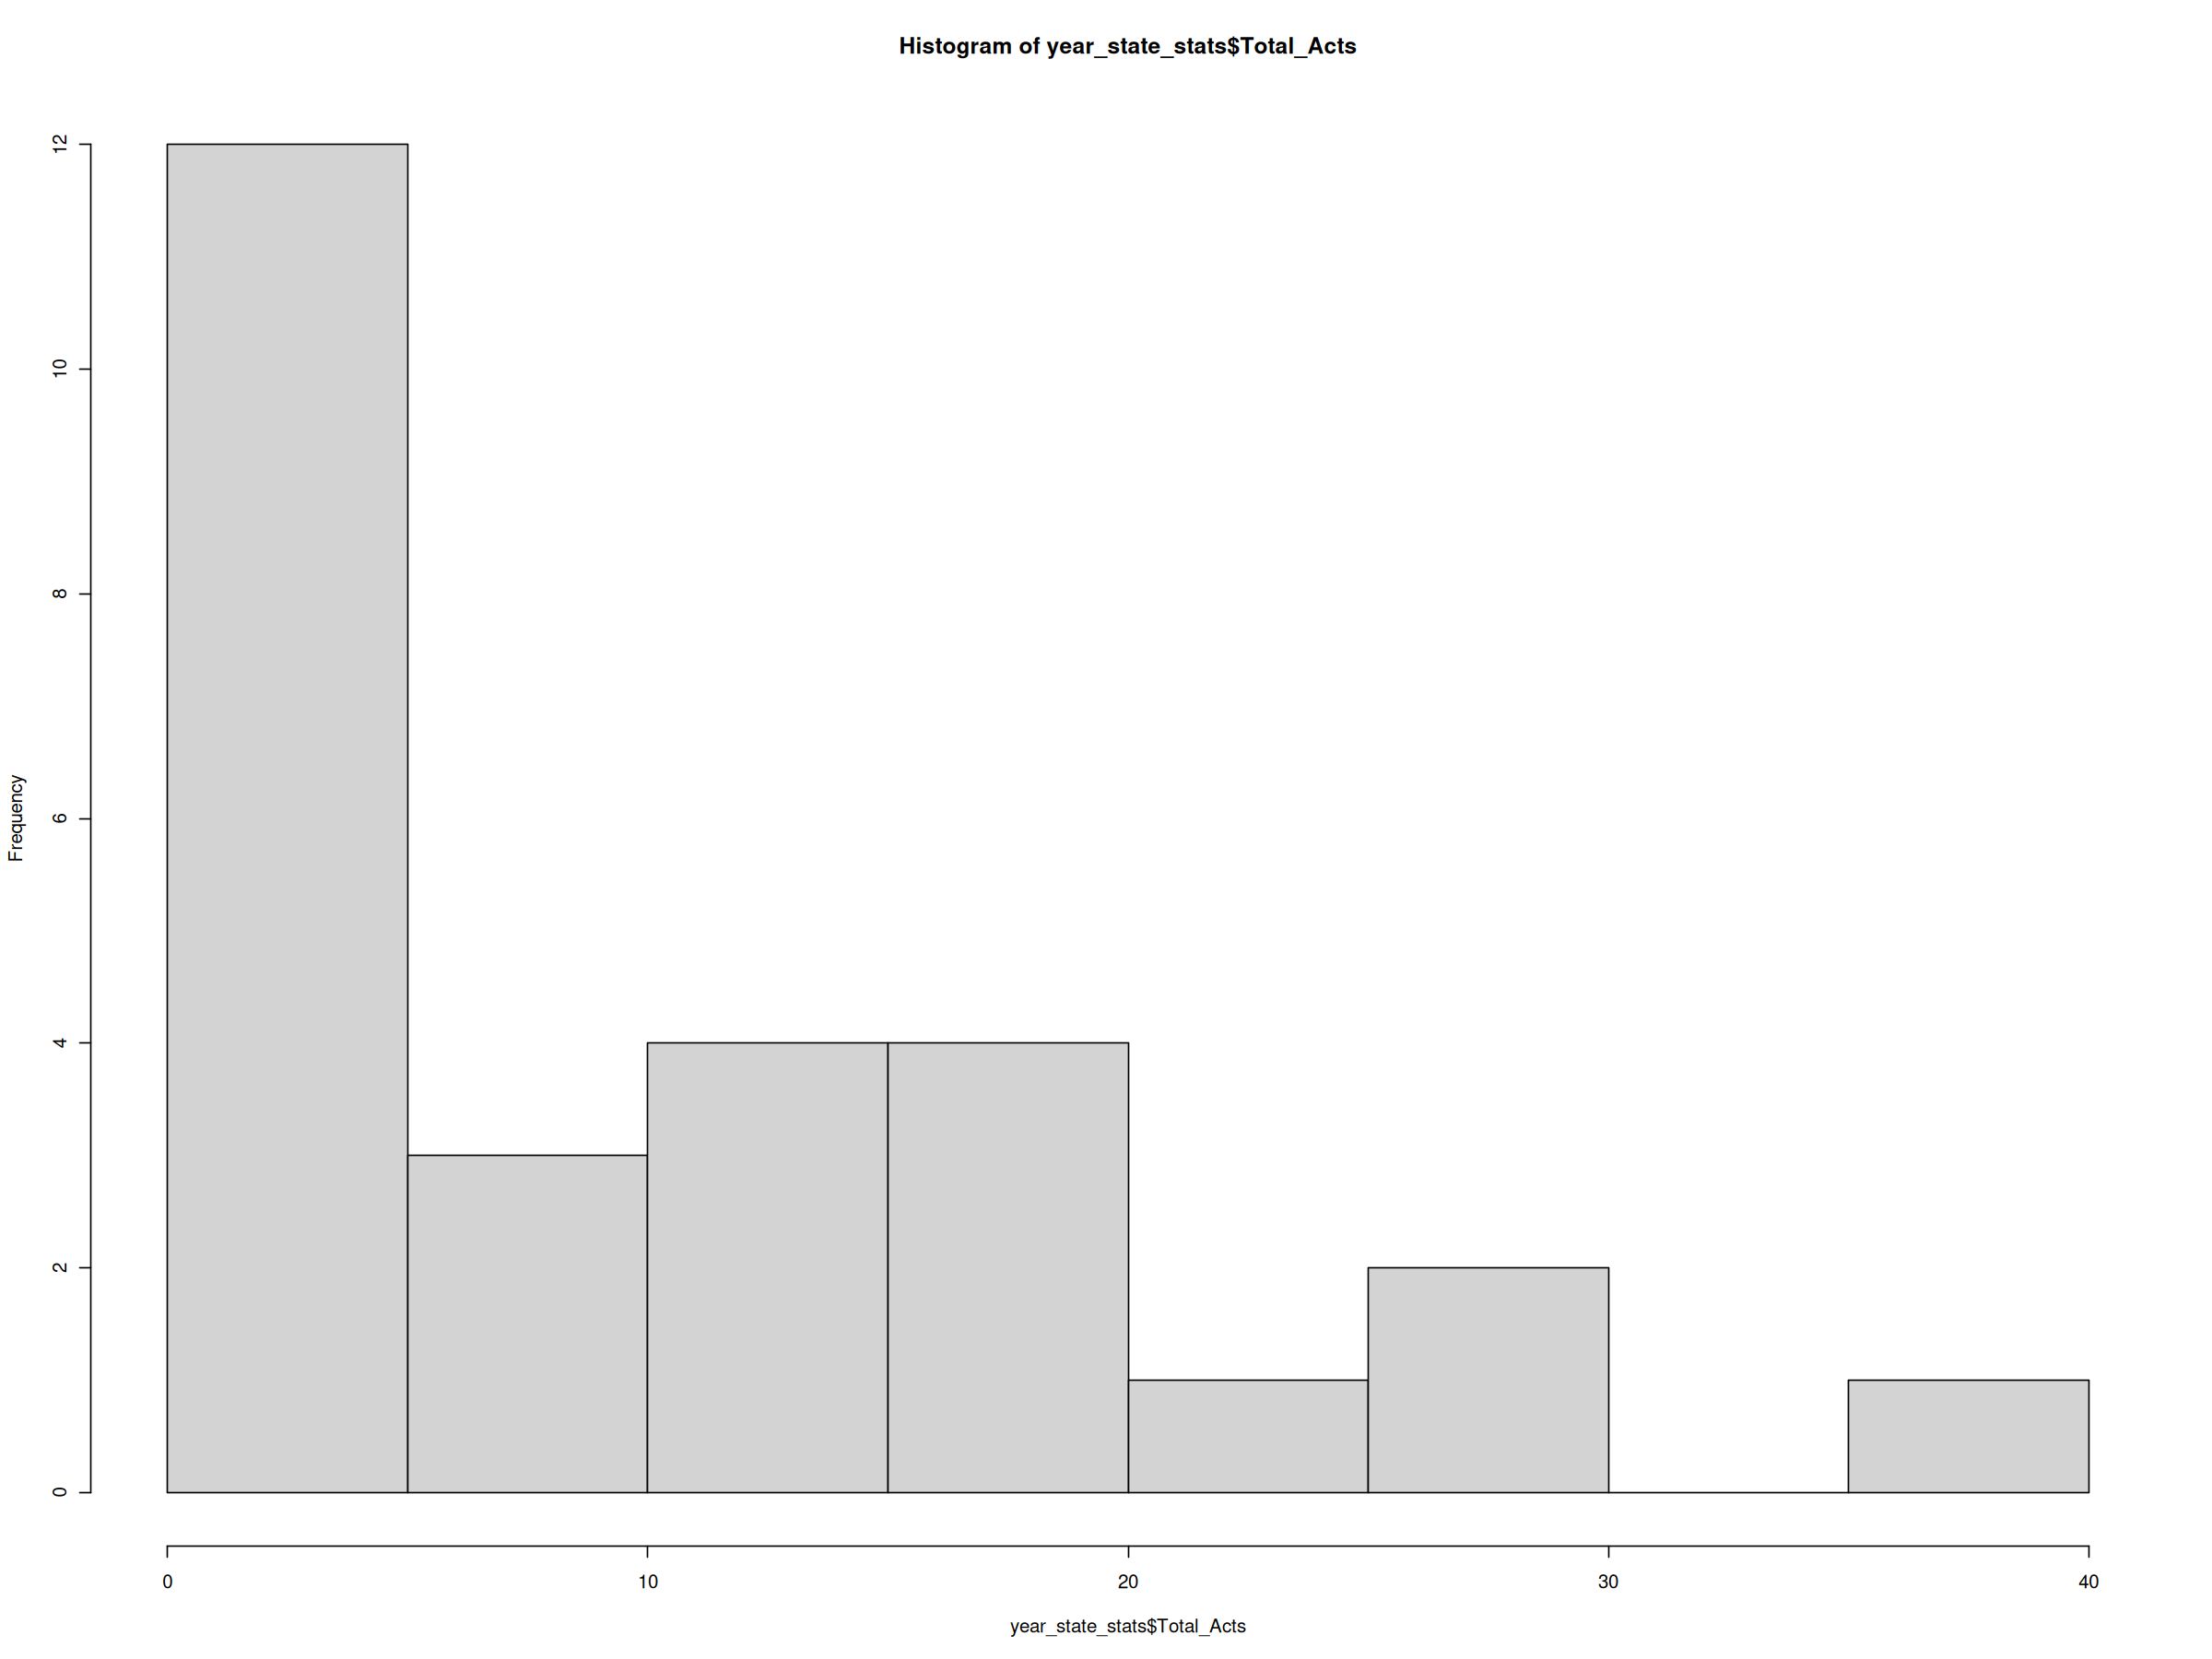

In [91]:
#Look at distribution of number of enacted laws
hist(state_stats$Acts) #enacted laws per state

hist(year_state_stats$Total_Acts) #total enacted laws across US states

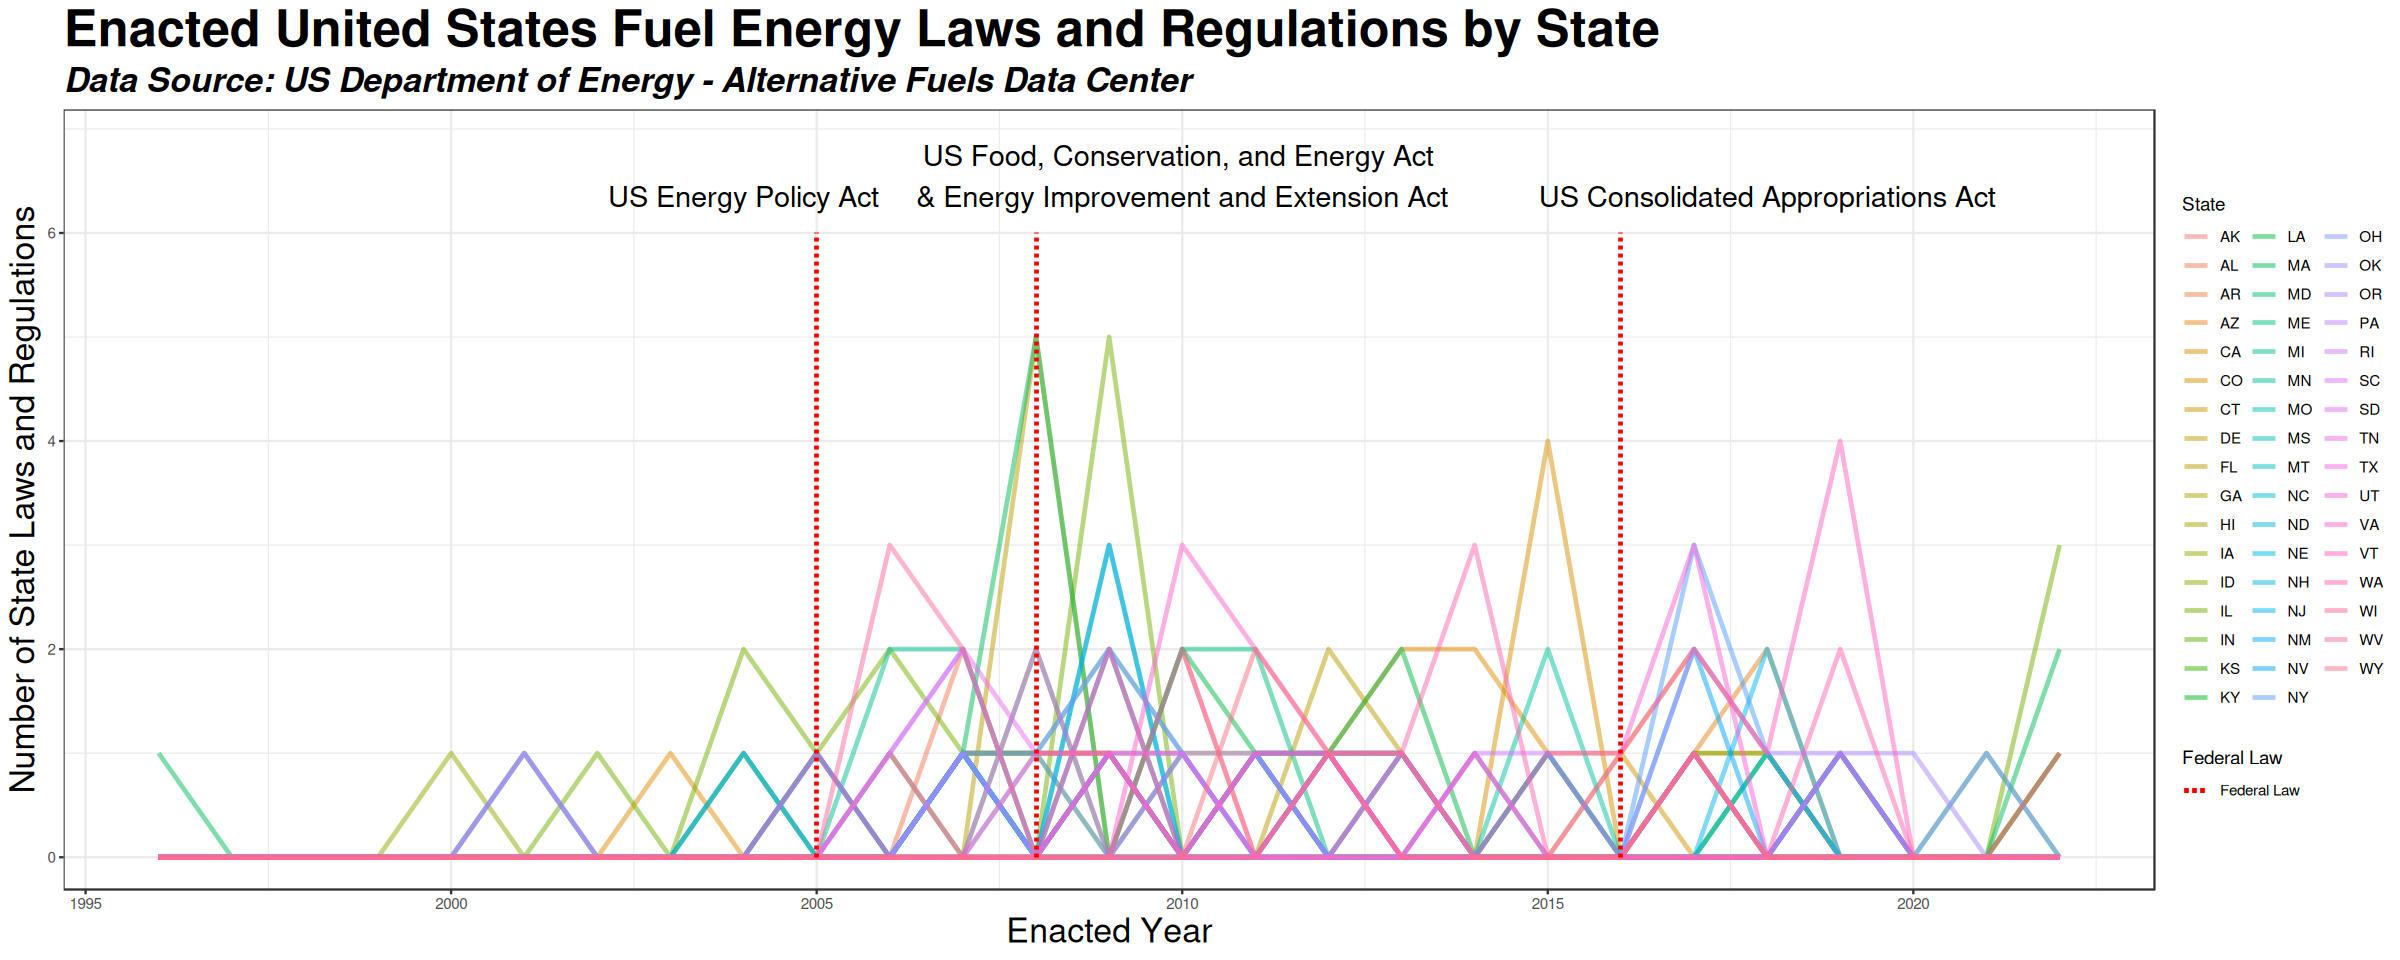

In [92]:
#trend analysis - plot each dataset on top of each other
options(repr.plot.width = 20, repr.plot.height = 8)

state_trendline <- ggplot() + 
    geom_line(data = state_stats, aes(x = Enacted.Year, y = Acts, group = State, color = State), alpha = 0.5, size = 1) + #totals per state
    
    #create second color scale for the geom_segments
    new_scale_color() +
    scale_color_manual(name = "Federal Law", 
                     values = "red") +

    ##################### add in federal acts ################

    #2005 - Energy Policy Act
    geom_segment(aes(x = 2005, xend = 2005, y = 0, yend = 6, color = "Federal Law"),
                linetype = "dashed", size = 1) + #vertical line cut below top of graph
    annotate("text", x = 2004, y = 6.25, 
             label = "US Energy Policy Act", 
             vjust = 0, color = "black", size = 6) + #text

    #2008
        #Food, Conservation, and Energy Act
        #Energy Improvement and Extension Act
    geom_segment(aes(x = 2008, xend = 2008, y = 0, yend = 6, color = "Federal Law"),
                linetype = "dashed", size = 1) + #vertical line cut below top of graph
    annotate("text", x = 2010, y = 6.25, 
              label = "US Food, Conservation, and Energy Act \n& Energy Improvement and Extension Act",
              vjust = 0, color = "black", size = 6) + #text

    #2016 - Consolidated Appropriations Act
    geom_segment(aes(x = 2016, xend = 2016, y = 0, yend = 6, color = "Federal Law"),
                linetype = "dashed", size = 1) + #vertical line cut below top of graph
    annotate("text", x = 2018, y = 6.25, 
             label = "US Consolidated Appropriations Act", 
             vjust = 0, color = "black", size = 6) + #text

    scale_y_continuous(expand = expansion(mult = c(0.05, 0.15))) + 

    ########################################################

    #labels
    labs(title = "Enacted United States Fuel Energy Laws and Regulations by State", 
             subtitle = "Data Source: US Department of Energy - Alternative Fuels Data Center", 
             x = "Enacted Year",
             y = "Number of State Laws and Regulations") +

    theme_bw() +
    theme(plot.title = element_text(size = 30, face = "bold"), # Adjust text sizes
          plot.subtitle = element_text(size = 20, face = "bold.italic"),
          axis.title = element_text(size = 20)
         ) 

state_trendline

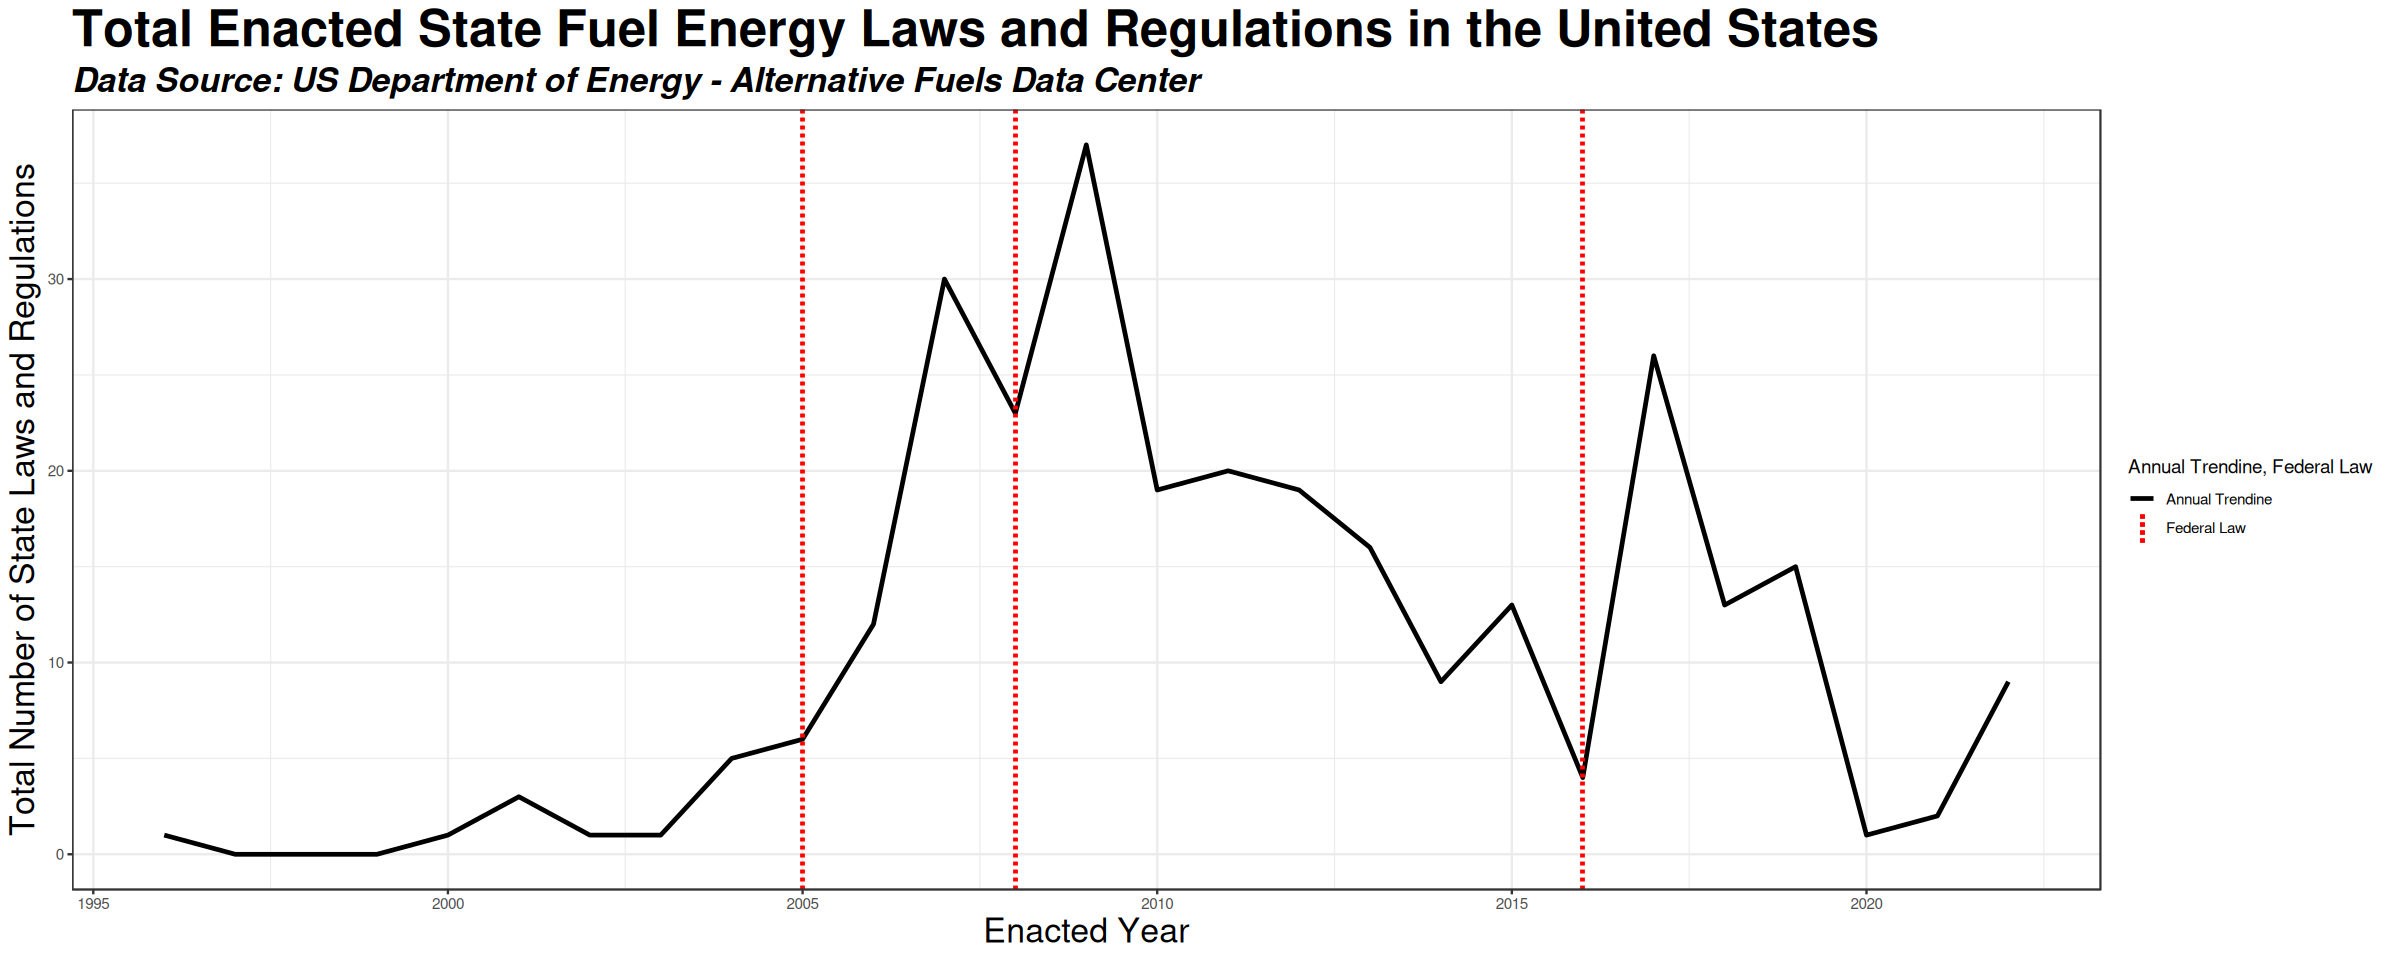

In [93]:
options(repr.plot.width = 20, repr.plot.height = 8)
US_trendline <- ggplot() + 

      #manual legend
      scale_color_manual(name = c("Annual Trendine, Federal Law"), #legend name
                         values = c("black", "red")) +    #color

    geom_line(data = year_state_stats, aes(x = Enacted.Year, y = Total_Acts, group = 1,  color = "Annual Trendine"), size = 1) + #US state total

    #add in US federal policy dates
    geom_vline(aes(xintercept = 2005, color = "Federal Law"), linetype = "dashed", size = 1) +
    geom_vline(aes(xintercept = 2008, color = "Federal Law"), linetype = "dashed", size = 1) +
    geom_vline(aes(xintercept = 2016, color = "Federal Law"), linetype = "dashed", size = 1) +

    #labels
    labs(title = "Total Enacted State Fuel Energy Laws and Regulations in the United States",  
             subtitle = "Data Source: US Department of Energy - Alternative Fuels Data Center", 
             x = "Enacted Year",
             y = "Total Number of State Laws and Regulations") +
    
    theme_bw() +
    theme(plot.title = element_text(size = 30, face = "bold"), # Adjust text sizes
          plot.subtitle = element_text(size = 20, face = "bold.italic"),
          axis.title = element_text(size = 20)
         ) 


US_trendline

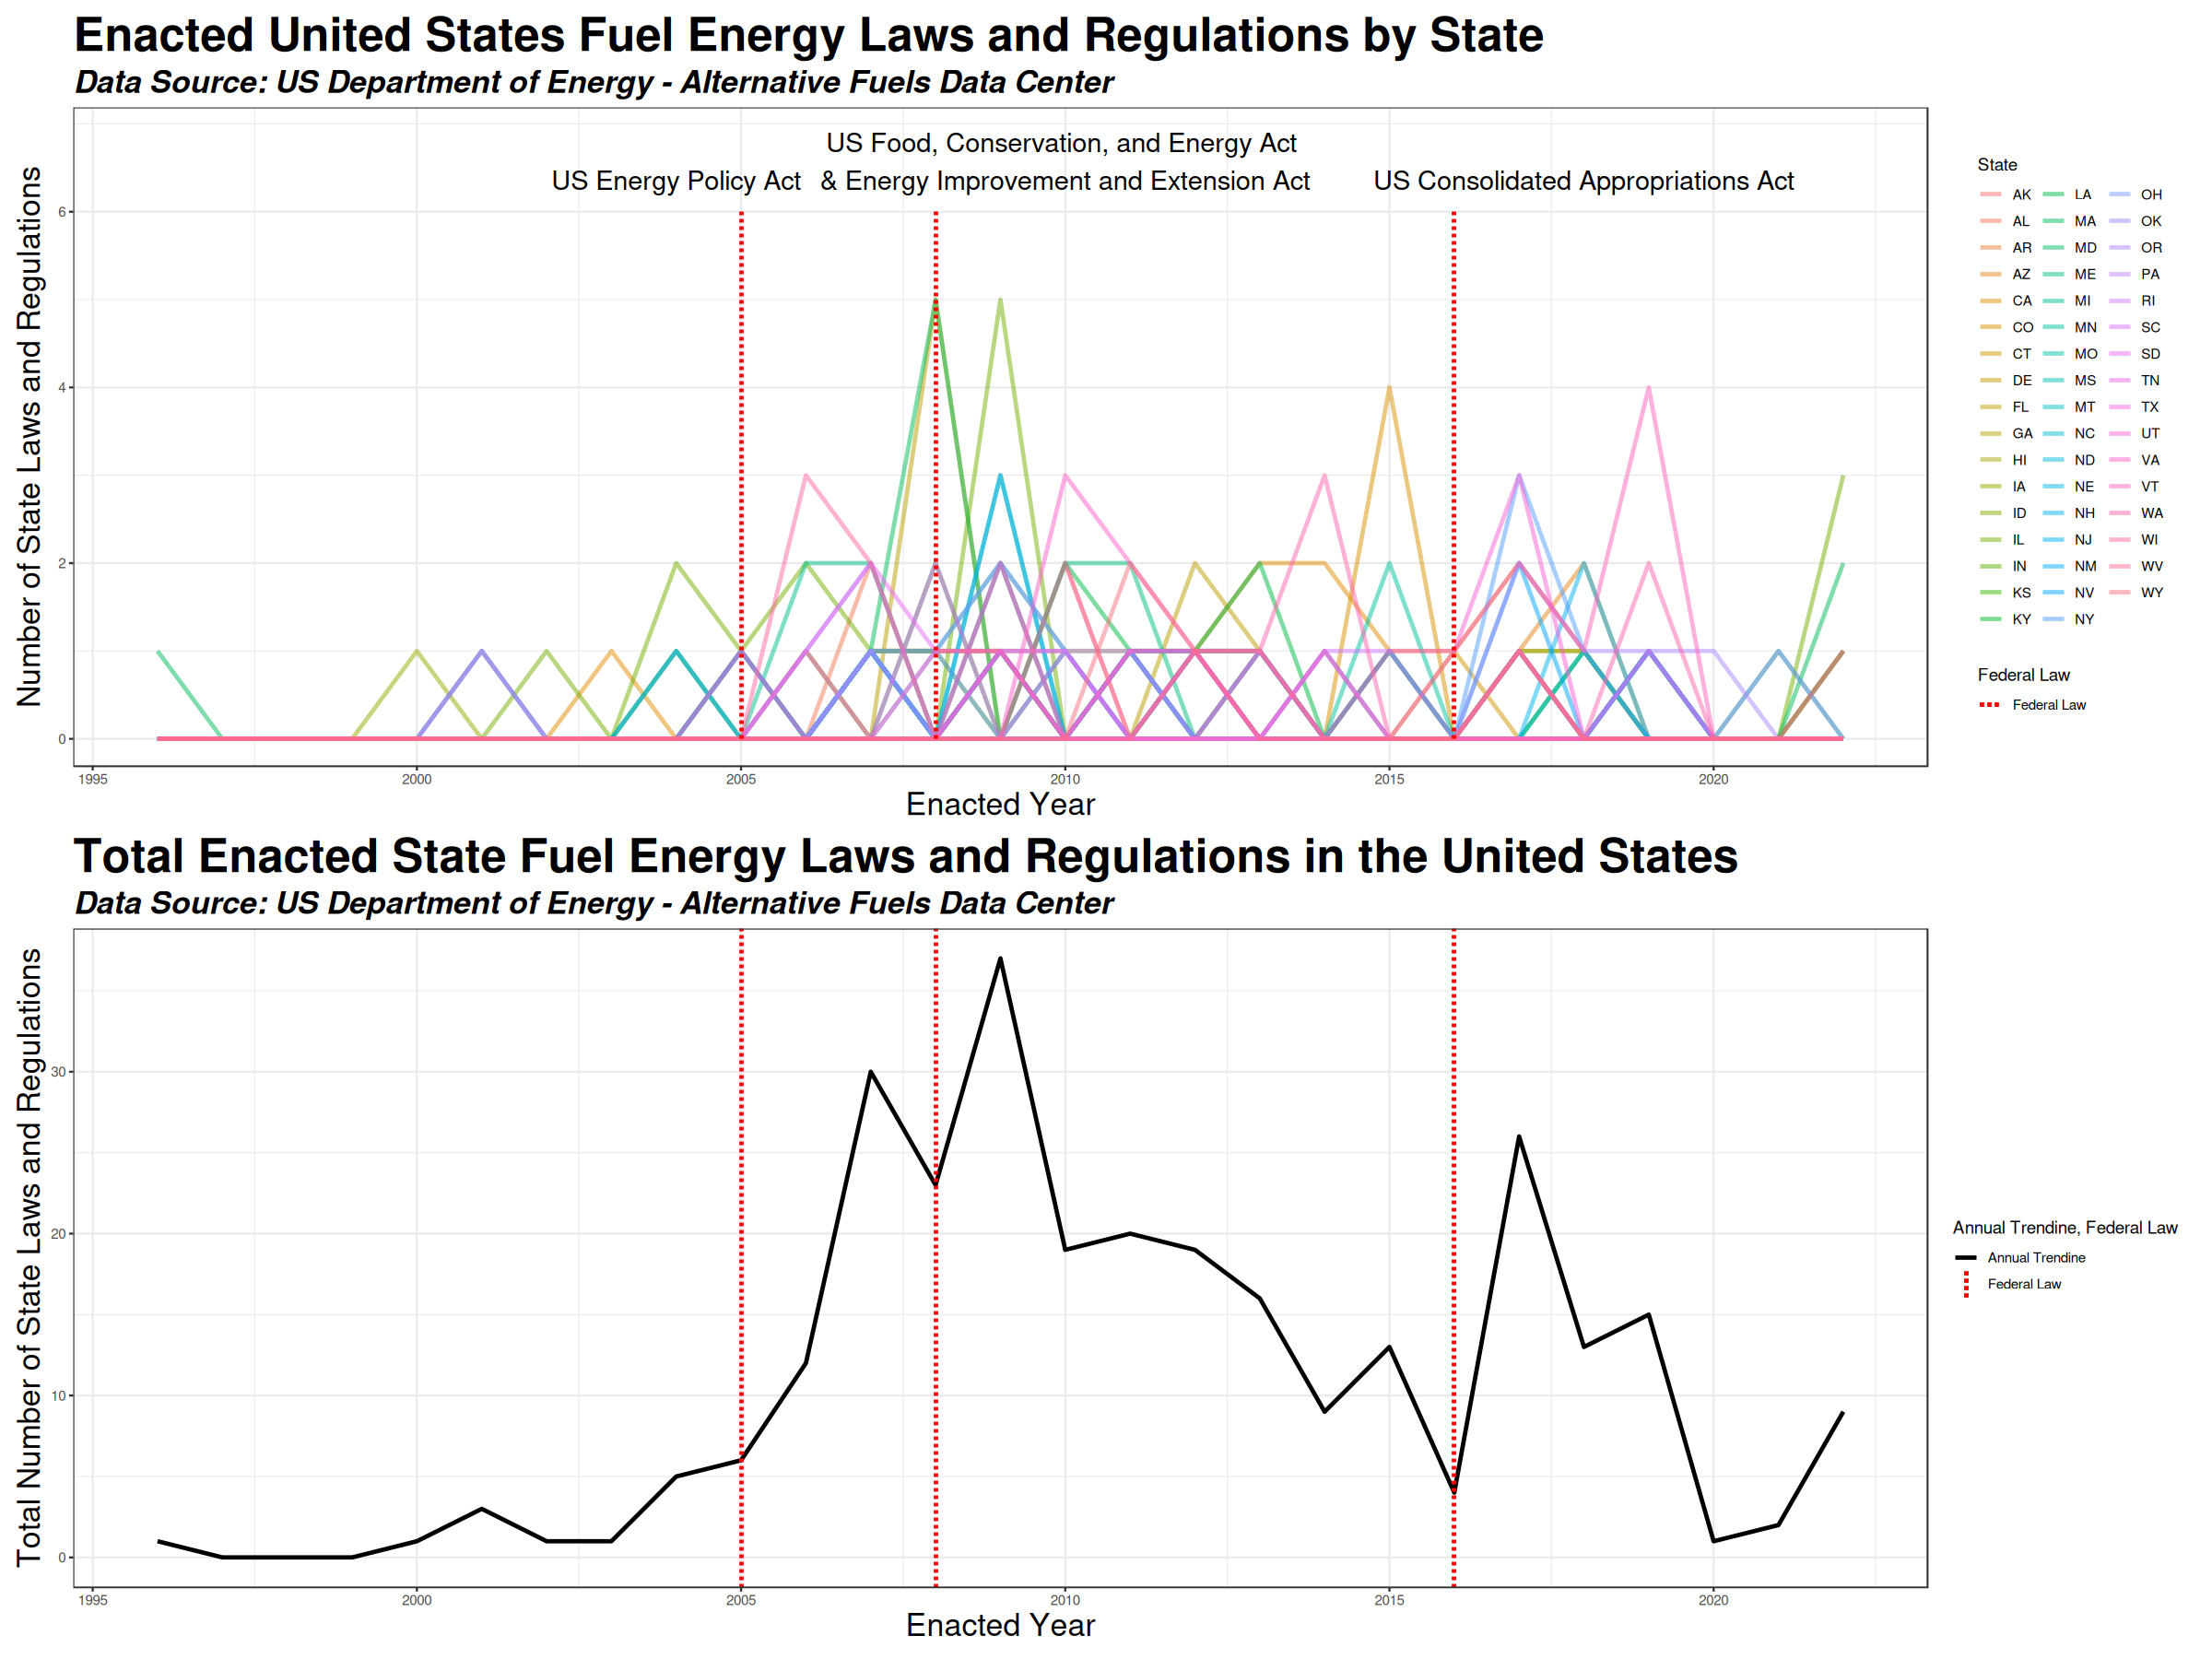

In [94]:
#combine graphs vertically
options(repr.plot.width = 20, repr.plot.height = 15)
combined_trends <- state_trendline / US_trendline
combined_trends

In [95]:
#save the plot
ggsave("descriptive_trendlines.png", plot = combined_trends, path = "/home/user/Capstone_March_2026/US_Renewable_Energy_EDS_Capstone/3.outputs", width = 50, height = 35, units = "cm")

## Final Analysis and Visualizations

<br>*Export a minimum of 2 visualizations (PDF, PNG or JPG). Each visualization should have a title, labeled x and y axis.* </br>

Relevant Lectures:
<br>**Course 3, Module 9**: "Helpful Data Visualizations for Data Cleaning and EDA" by JRS — Introduces helpful visualizations for EDA step.</br>
<br>**Course 5, Module 17**: "Data Visualizations and Communication" by Simon Queenborough — Discusses effective data visualization techniques.</br>



In [105]:
#peaks to target - beginning = year to start at
peak_years <- c(2007, 2009, 2017)
peak_data <- year_state_stats %>%
    filter(Enacted.Year == 2009 | Enacted.Year == 2007 | Enacted.Year == 2017)   

peak_data

Enacted.Year,Total_Acts
<dbl>,<int>
2007,30
2009,37
2017,26


In [96]:
#peak federal acts
federal_act_years <- c(2005, 2008, 2016)
federal_act_names <- c("2005 - Energy Policy Act",
                       "2008 - Energy Improvement and Extension Act and \nFood, Conservation and Energy Act", 
                       "2016 - Consolidated Appropriations Act")

In [97]:
########## Loop through federal act list to create before/act groupings ###################
#list to store loop results
state_comparison_list <- list()

for (i in 1:length(federal_act_years)) { #loop through federal_act_years
    
    #specify year and name for each act
    act  <- federal_act_years[i]
    name <- federal_act_names[i]
    
    temp_state_data <- state_stats %>% #create temporary dataset to loop through
        filter(Enacted.Year >= (act - 3) & Enacted.Year <= (act + 2)) %>% #3years before and 3 years after (including enacted year)
        mutate(
            Federal_Act_Year = act,
            Act_Status = if_else(Enacted.Year >= act, "After_Act", "Before_Act"),
            Act_Status = factor(Act_Status, levels = c("Before_Act", "After_Act"))
        )
   
     state_comparison_list[[as.character(act)]] <- temp_state_data #store temp data
     print(paste("Dataset for:", name))
     print(head(temp_state_data))
}
state_comparison_list <- bind_rows(state_comparison_list) #combine all results into one dataframe

[1] "Dataset for: 2005 - Energy Policy Act"
# A tibble: 6 × 5
  State Enacted.Year  Acts Federal_Act_Year Act_Status
  <chr>        <dbl> <int>            <dbl> <fct>     
1 AK            2002     0             2005 Before_Act
2 AK            2003     0             2005 Before_Act
3 AK            2004     0             2005 Before_Act
4 AK            2005     0             2005 After_Act 
5 AK            2006     0             2005 After_Act 
6 AK            2007     0             2005 After_Act 
[1] "Dataset for: 2008 - Energy Improvement and Extension Act and \nFood, Conservation and Energy Act"
# A tibble: 6 × 5
  State Enacted.Year  Acts Federal_Act_Year Act_Status
  <chr>        <dbl> <int>            <dbl> <fct>     
1 AK            2005     0             2008 Before_Act
2 AK            2006     0             2008 Before_Act
3 AK            2007     0             2008 Before_Act
4 AK            2008     0             2008 After_Act 
5 AK            2009     0             2008 Aft

`summarise()` has grouped output by 'Federal_Act_Year'. You can override using
the `.groups` argument.


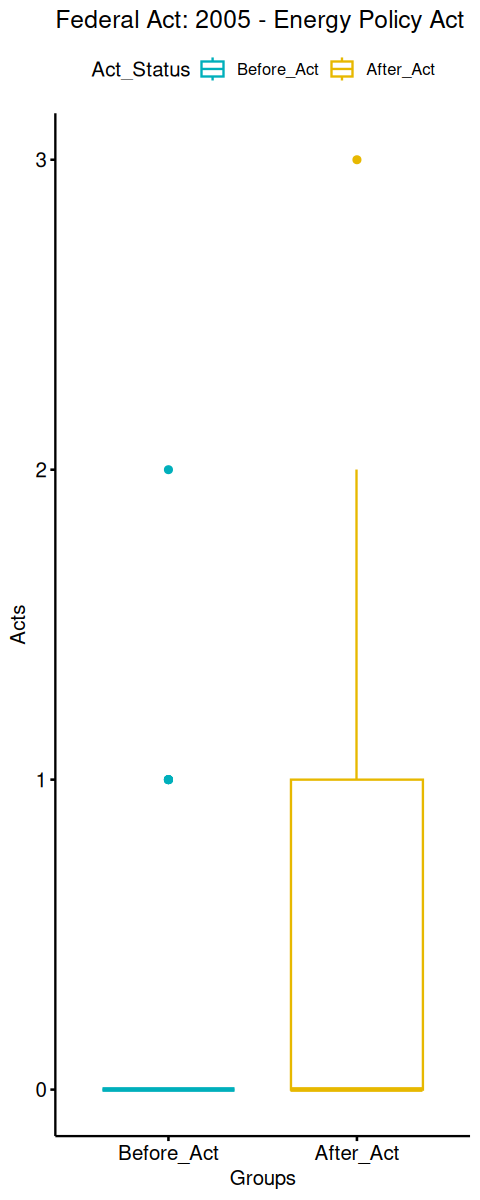

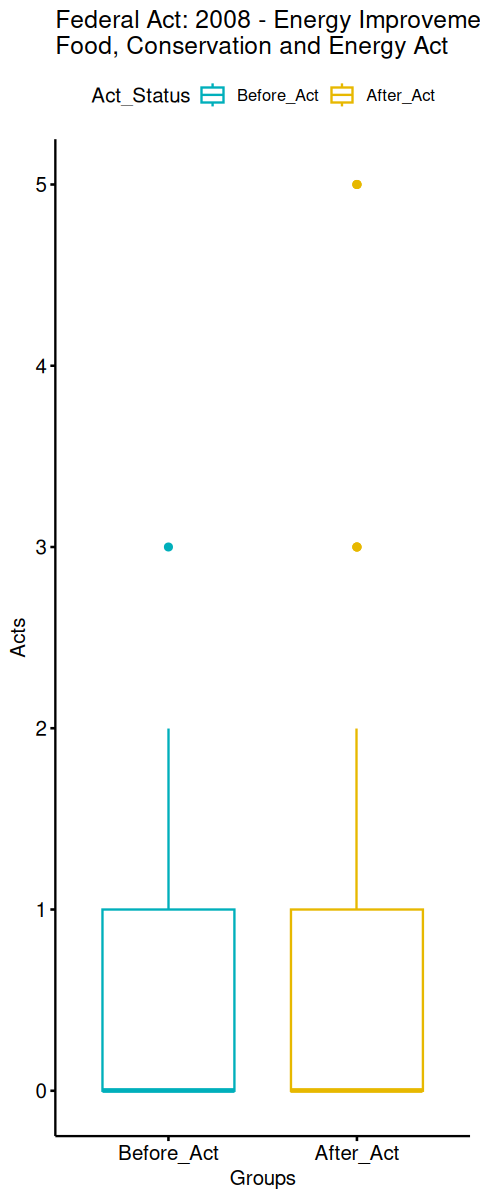

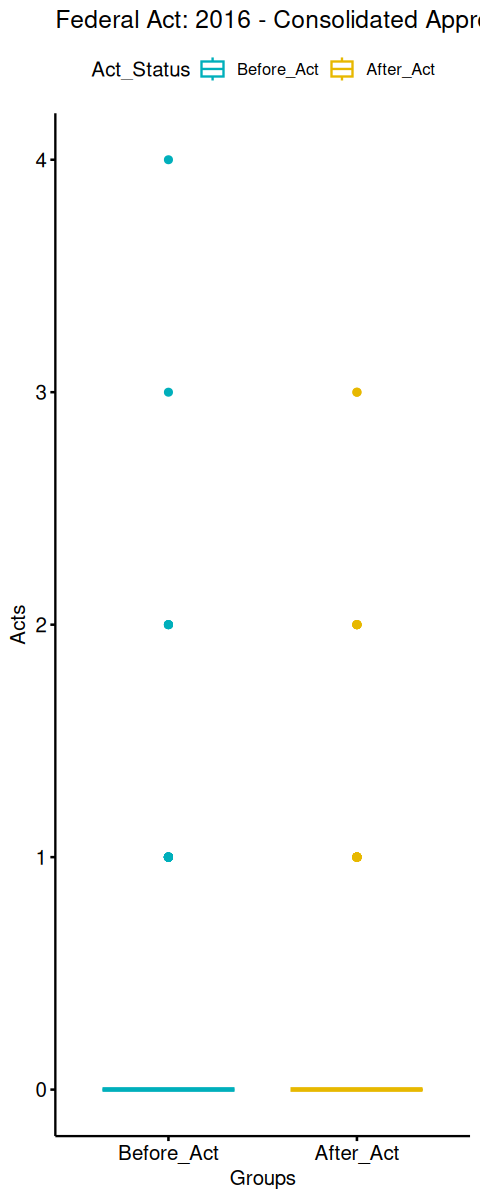

In [98]:
########## create summary statistics for each federal act for box plots ###################

#summary stats
US_act_stats <- state_comparison_list %>%
    group_by(Federal_Act_Year, Act_Status) %>%
       summarise(
        count = n(),
        median = median(Acts, na.rm = TRUE),
        average = round(mean(Acts, na.rm = TRUE),3),
        IQR = IQR(Acts, na.rm = TRUE)
  )

################# create individual datasets based on federal act years ###################

US_act_2005_stats <- state_comparison_list %>%
    filter(Federal_Act_Year == 2005)

US_act_2008_stats <- state_comparison_list %>%
    filter(Federal_Act_Year == 2008)

US_act_2016_stats <- state_comparison_list %>%
    filter(Federal_Act_Year == 2016)

################################### create box plots ######################################

options(repr.plot.width = 4, repr.plot.height = 10)

state_compare <- list(
                 US_act_2005_stats,
                 US_act_2008_stats,
                 US_act_2016_stats
            ) #keep dataframes instead of flat vectors

boxplot_list <- list()

for (i in 1:length(state_compare)){
    compare_boxplot <- ggboxplot(state_compare[[i]], 
              x = "Act_Status", 
              y = "Acts", 
              color = "Act_Status", 
              palette = c("#00AFBB", "#E7B800")) +
              labs(
                  title = paste("Federal Act:", federal_act_names[i]),
                  subcaption = "Boxplot distribution of state acts made betweeen 2000 and 2010\n Data: US Department of Energy - Alternative Fuels Data Center",
                  x = "Groups", 
                  y = "Acts")
    print(compare_boxplot)
    
     boxplot_list[[i]] <- compare_boxplot # Save the plot object to the list
    }

In [101]:
######################## use above datasets for paired box plots ##########################
options(repr.plot.width = 5, repr.plot.height = 8)

#combine all new datasets into a list to loop through
compare <- list(
                 US_act_2005_stats,
                 US_act_2008_stats,
                 US_act_2016_stats
            ) #keeps dataframes instead of flat vectors

Warning message in wilcox.test.default(before, after, paired = TRUE):
“cannot compute exact p-value with ties”


Warning message in wilcox.test.default(before, after, paired = TRUE):
“cannot compute exact p-value with zeroes”



	Wilcoxon signed rank test with continuity correction

data:  before and after
V = 0, p-value = 1.898e-06
alternative hypothesis: true location shift is not equal to 0



`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


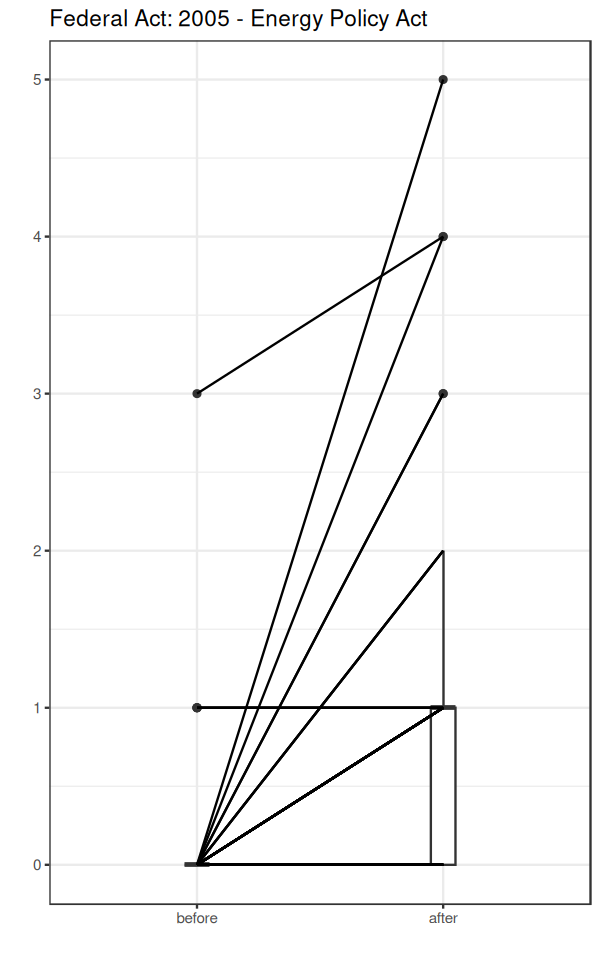

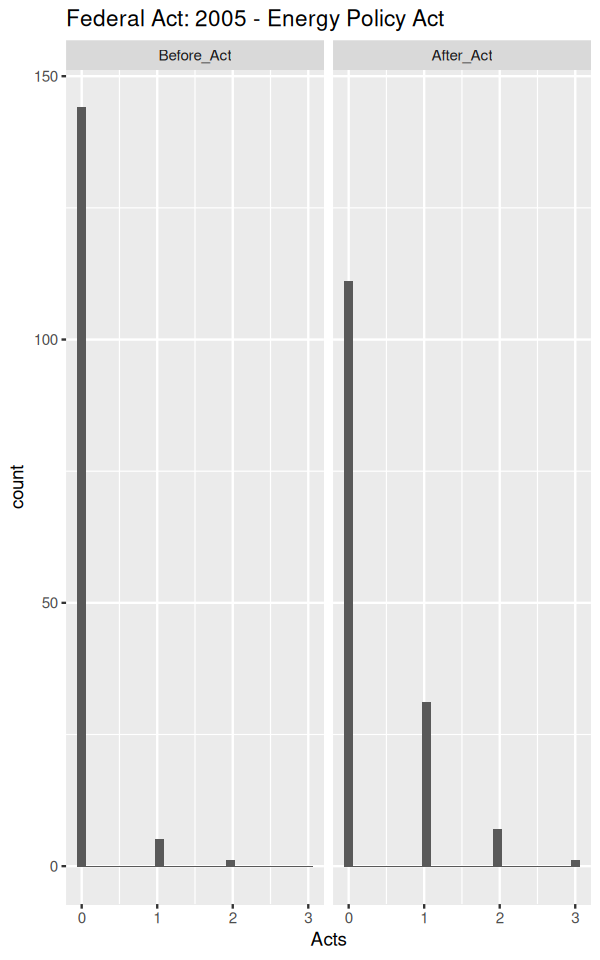

Warning message in wilcox.test.default(before, after, paired = TRUE):
“cannot compute exact p-value with ties”


Warning message in wilcox.test.default(before, after, paired = TRUE):
“cannot compute exact p-value with zeroes”



	Wilcoxon signed rank test with continuity correction

data:  before and after
V = 181, p-value = 0.007375
alternative hypothesis: true location shift is not equal to 0



`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


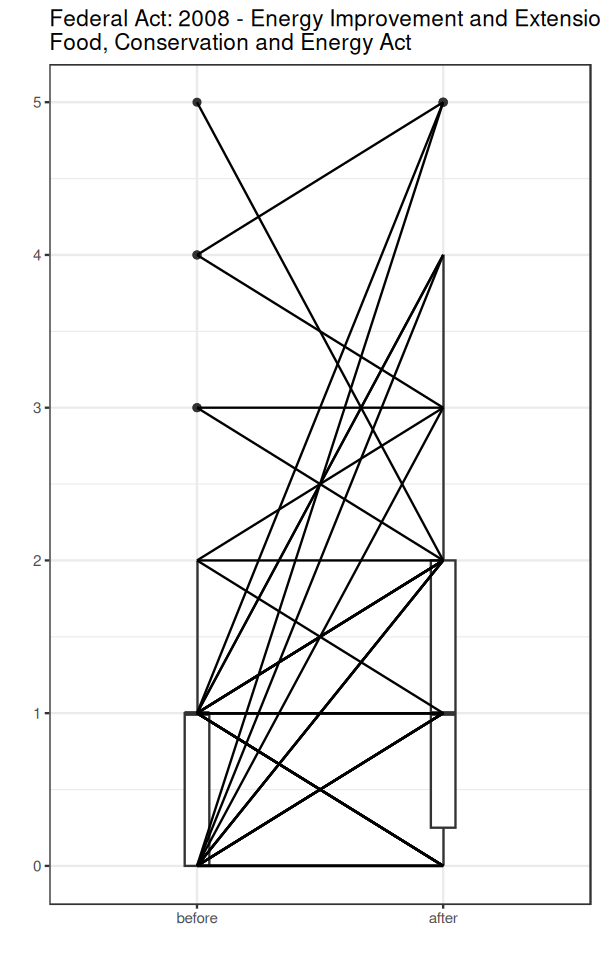

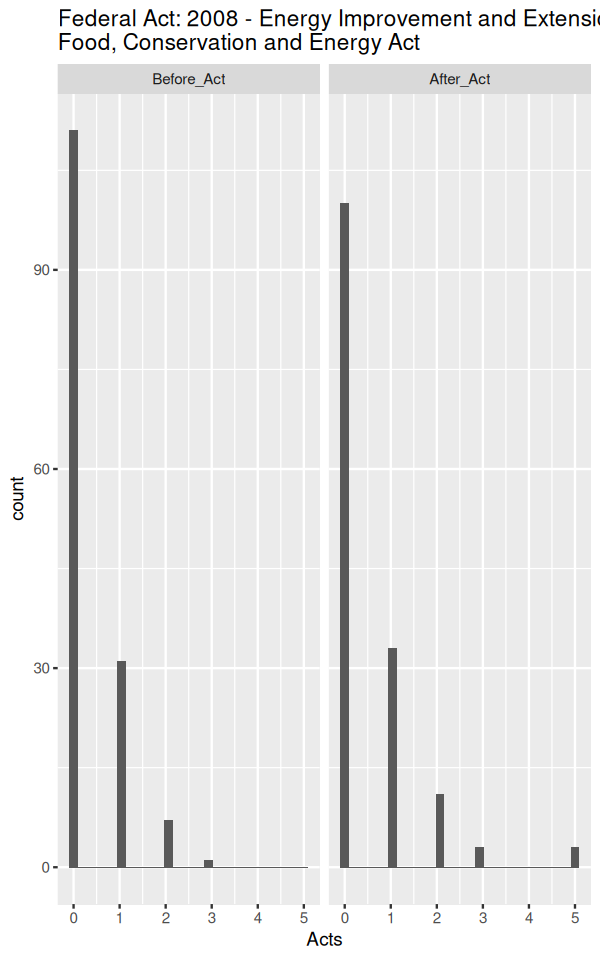

Warning message in wilcox.test.default(before, after, paired = TRUE):
“cannot compute exact p-value with ties”


Warning message in wilcox.test.default(before, after, paired = TRUE):
“cannot compute exact p-value with zeroes”



	Wilcoxon signed rank test with continuity correction

data:  before and after
V = 215, p-value = 0.7192
alternative hypothesis: true location shift is not equal to 0



`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


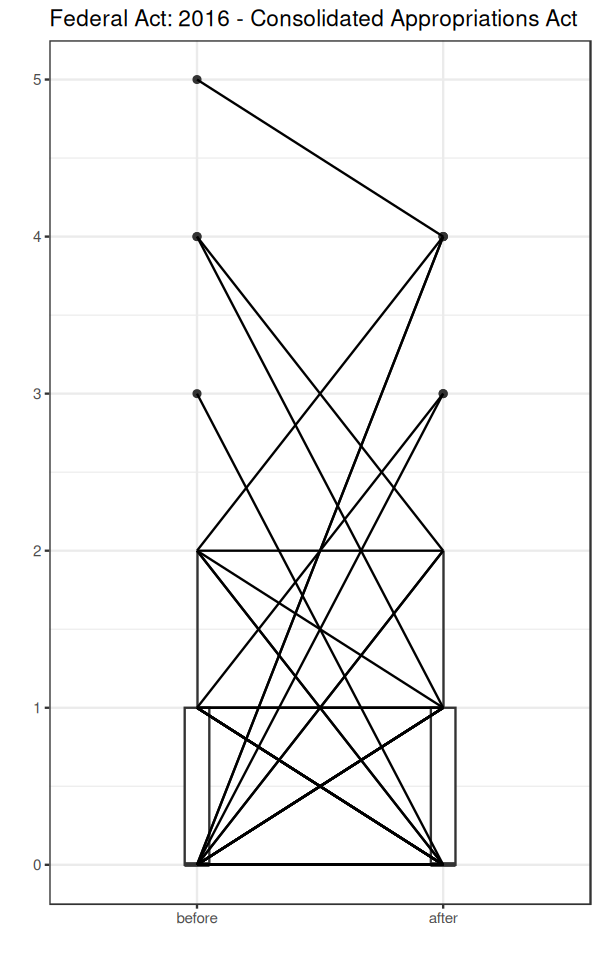

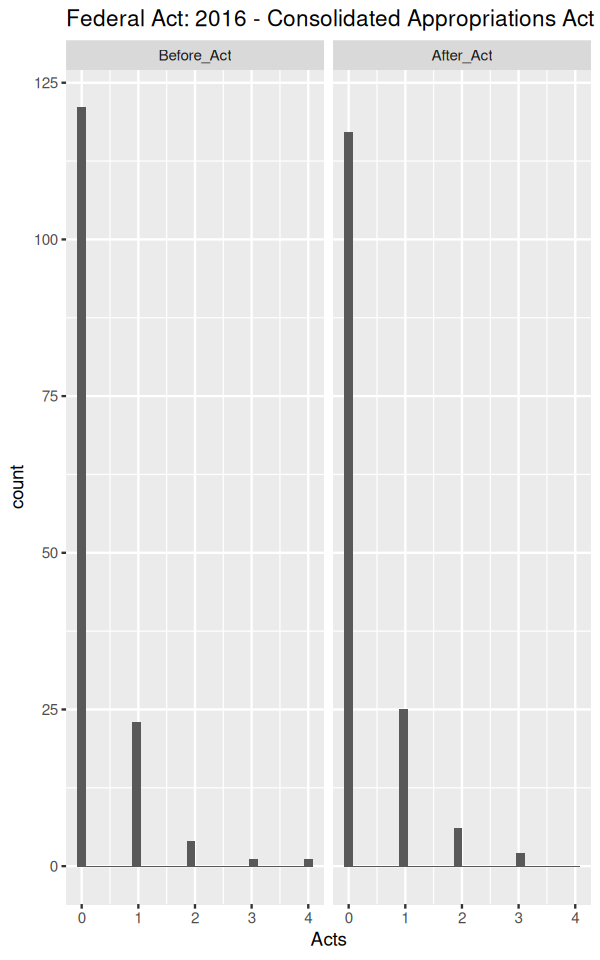

In [102]:
######################## use above datasets for paired box plots ##########################
options(repr.plot.width = 5, repr.plot.height = 6)

#combine all new datasets into a list to loop through
compare <- list(
                 US_act_2005_stats,
                 US_act_2008_stats,
                 US_act_2016_stats
            ) #keeps dataframes instead of flat vectors

options(repr.plot.width = 5, repr.plot.height = 8)

for (i in 1:length(compare)){
    
    # Include State in group_by to maintain multiple observations
    US_paired_clean <- compare[[i]] %>%
        group_by(State, Act_Status) %>% 
        summarise(Acts = sum(Acts, na.rm = TRUE), .groups = "drop") %>%
        pivot_wider(names_from = Act_Status, values_from = Acts) %>%
        drop_na()

    before <- US_paired_clean$Before_Act
    after  <- US_paired_clean$After_Act

    # Create the paired object and plot
    pd <- paired(before, after)
    paired_boxplot <- plot(pd, type = "profile") + theme_bw() +
       labs(title = paste("Federal Act:", federal_act_names[i]))
    
    print(paired_boxplot)
    
    res <- wilcox.test(before, after, paired = TRUE) #wilcoxon t-test
    print(res) #p < 0.05 = significant difference
    
    histogram <- ggplot(compare[[i]], aes(x = Acts)) +
      geom_histogram() +
      facet_wrap(~ Act_Status) +
      labs(title = paste("Federal Act:", federal_act_names[i]))
    
    print(histogram)
    
}

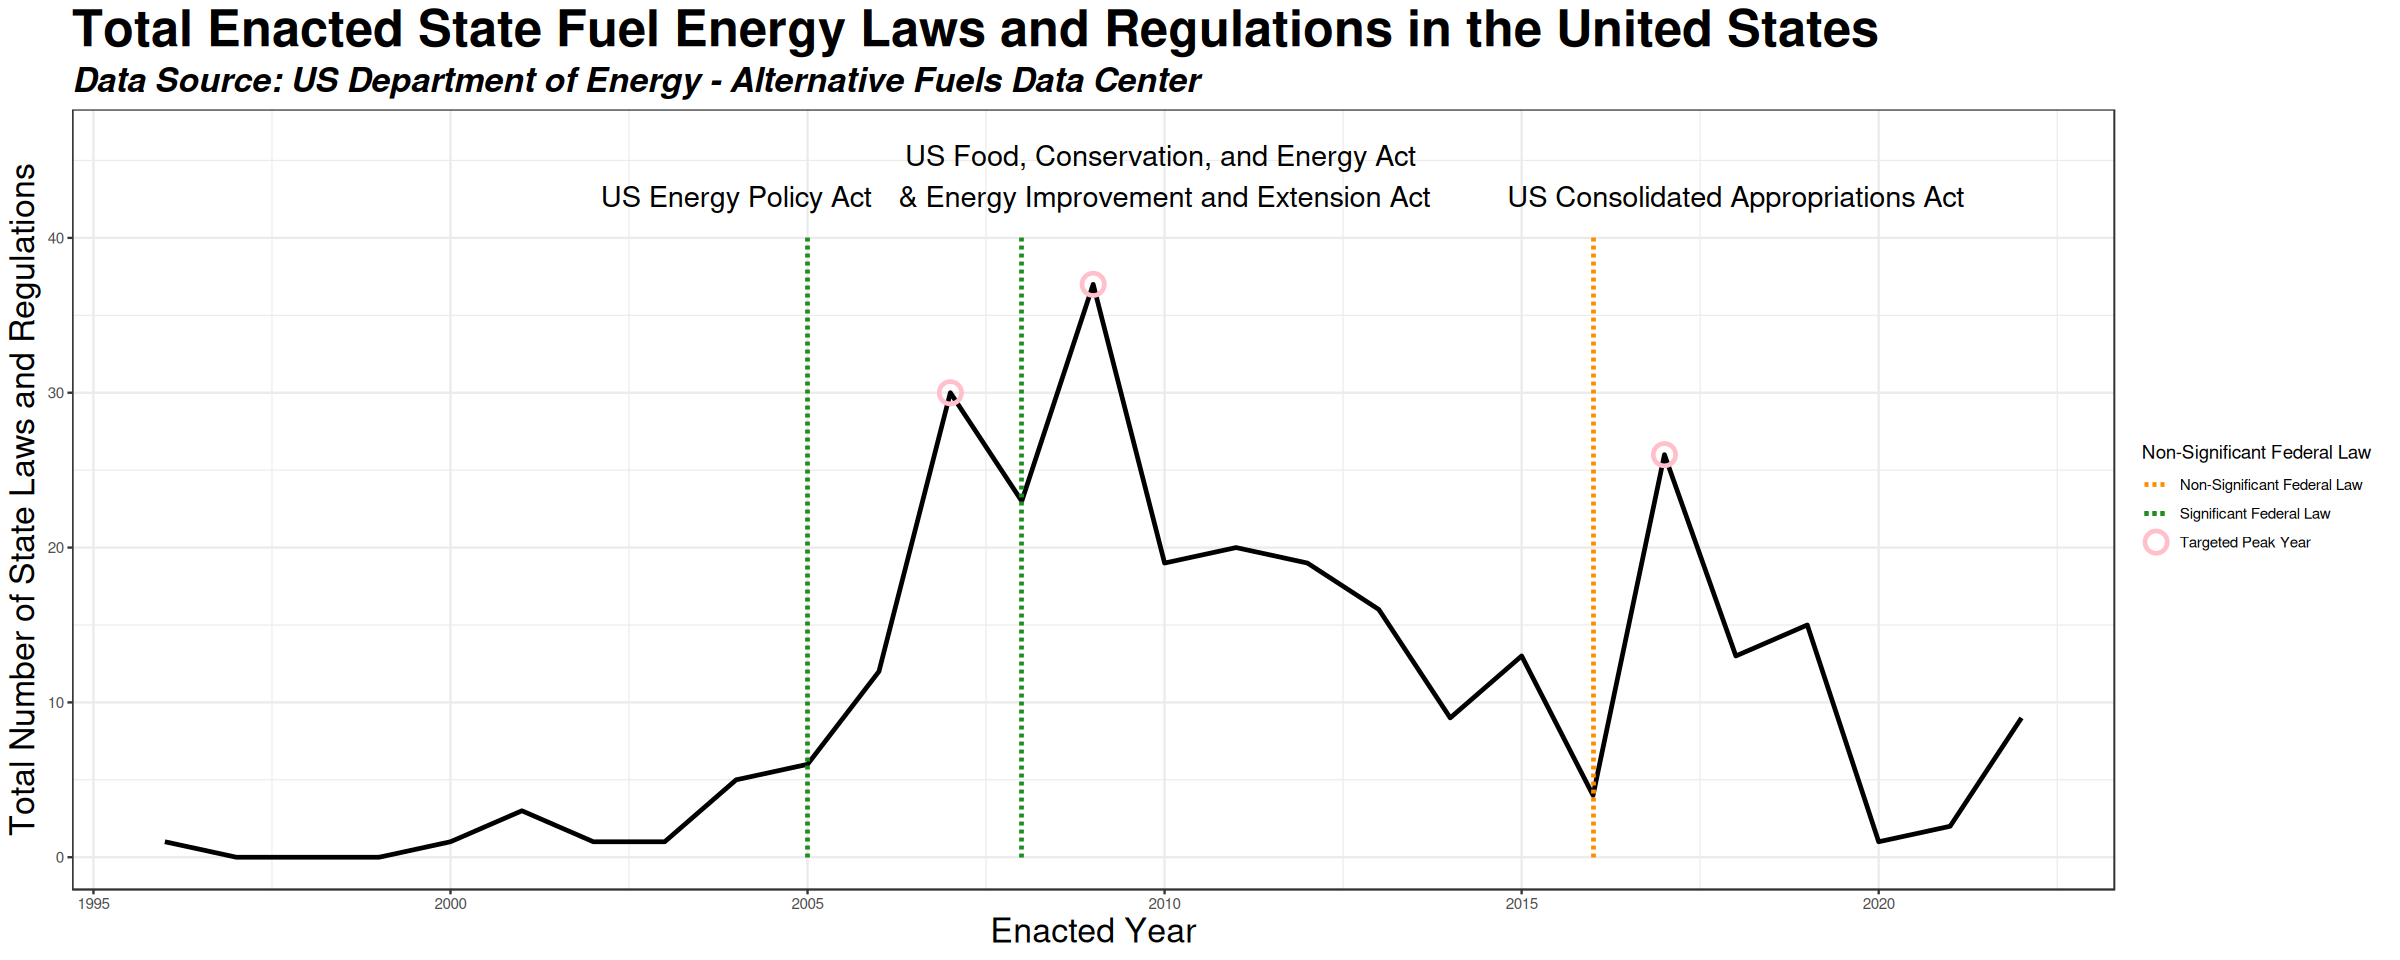

In [107]:
options(repr.plot.width = 20, repr.plot.height = 8)
trendline_results <- ggplot() + 
    geom_line(data = year_state_stats, aes(x = Enacted.Year, y = Total_Acts, group = 1), color = "black", size = 1) + 
    #US state total

     #manual legend for targeted peaks and geom_segments
      scale_color_manual(name = c("Non-Significant Federal Law", "Significant Federal Law", "Targeted Peak Year"), #legend name
                         values = c("darkorange", "forestgreen", "pink")) +    #color

    ######################### add peaks ################################

    #circle targeted peaks
      geom_point(
                data = peak_data, 
                aes(x = Enacted.Year, y = Total_Acts, color = "Targeted Peak Year"),
                shape = 1,      # Shape 1 is an open circle
                size = 5,       # Make the circle large
                stroke = 1.5   # Make the circle line thicker
              ) +

    ##################### add in federal acts ################

    #2005 - Energy Policy Significant Federal Law
    geom_segment(aes(x = 2005, xend = 2005, y = 0, yend = 40, color = "Significant Federal Law"), 
                 #color = "Significant",
                 linetype = "dashed", size = 1) + #vertical line cut below top of graph
    annotate("text", x = 2004, y = 42, 
             label = "US Energy Policy Act", 
             vjust = 0, color = "black", size = 6) + #text

    #2008
        #Food, Conservation, and Energy Act
        #Energy Improvement and Extension Act
    geom_segment(aes(x = 2008, xend = 2008, y = 0, yend = 40, color = "Significant Federal Law"), 
                 #color = "Significant", 
                 linetype = "dashed", size = 1) + #vertical line cut below top of graph
     annotate("text", x = 2010, y = 42, 
              label = "US Food, Conservation, and Energy Act \n& Energy Improvement and Extension Act",
              vjust = 0, color = "black", size = 6) + #text

    #2016 - Consolidated Appropriations Act
    geom_segment(aes(x = 2016, xend = 2016, y = 0, yend = 40, color = "Non-Significant Federal Law"),
                 #color = "darkorange", 
                 linetype = "dashed", size = 1) + #vertical line cut below top of graph
    annotate("text", x = 2018, y = 42, 
             label = "US Consolidated Appropriations Act", 
             vjust = 0, color = "black", size = 6) + #text

    scale_y_continuous(expand = expansion(mult = c(0.05, 0.15))) + 

    ##################### labels ################
    labs(title = "Total Enacted State Fuel Energy Laws and Regulations in the United States",  
             subtitle = "Data Source: US Department of Energy - Alternative Fuels Data Center", 
             x = "Enacted Year",
             y = "Total Number of State Laws and Regulations") +
    
    theme_bw() +
    theme(plot.title = element_text(size = 30, face = "bold"), # Adjust text sizes
          plot.subtitle = element_text(size = 20, face = "bold.italic"),
          axis.title = element_text(size = 20)
         ) 

trendline_results

In [34]:
#save the plot
ggsave("trendline_results.png", plot = trendline_results, path = "/home/user/Capstone_March_2026/US_Renewable_Energy_EDS_Capstone/3.outputs", width = 50, height = 35, units = "cm")

## Ethical Considerations

- Privacy: The dataset does not contain personal data.
- Governance: Data used is openly available and ethically sourced at the US Department of Energy Alternative Fuels Data Center \([https://afdc.energy.gov/laws/state\\](https://afdc.energy.gov/laws/state%5C)\)
  - When downloading data choose the laws and incentives dataset, All option for Jurisdiction, Technology, Incentive Type, Regulation Type and User Types, Expired is No and csv format.
- Bias: Potential biases are that this dataset is not specifically labeled as clean energy and otherwise labeled as a alternative fuels which includes all energy sources, renewable and non renewable.

## Acknowledging Limitations

*In 1-2 sentences, acknowledge any limitations of your data or analysis.*

Relevant Lectures:
<br>**Course 3, Module 8**: "Handling Data Anomalies" by Angel — Discusses how to handle data anomalies and understand the limitations of your data.</br>

The analysis is based on the Laws and Incentives dataset on the US Department of Energy Alternative Fuels Data Center website, which may have limitations such as:

- Limited scope: Laws and regulations have the same enforcement requirements, but regulations are extensions of the laws and are not legally viewed as the same.
- Data quality: There are not enacted dates for every single law/regulation so those without an enacted date were not used for analysis because they would not be categorized to a specific year.

## Results for Non-Technical Audience

*In 1-2 sentences, explain the results of your analysis to a non-technical audience and the implications of your results for your environmental topic.*

Relevant Lectures:
<br>**Course 5, Module 15**: "Turning Data into Action" by Denice Ross — Discusses strategies for communicating results to a non\-technical audience.</br>

The federal government in the United States and sets a precedent for the states underneath them and their support for clean/renewable energy has been volatile for the past few decades with shifts in power.

Individuals and/or business who would like to see the the continuation of the clean energy transition within their communities may be feeling uncertain with the changes in the federal government. 

However, we can measure how influential federal energy laws and policies are by comparing the amount of state clean energy laws and regulations before and after the federal government energy laws are enacted. 

In my research, I have found that 2 out of 3 federal acts were significant source for the creation of clean energy policies in the states and that the federal government does not always have impact every state energy decision.

## Instructions for Reproducing Project

*Describe the steps someone else would need to take to reproduce your project.*
Relevant Lectures:
<br>**Course 2, Module 6**: "Addressing Version Control and Reproducibility" by Mitch — Explains the importance and strategies for version control.</br>
<br>**Course 4, Module 14**: "Creating Data Visualizations for EDA" by JRS — Provides guidance on reproducible EDA practices.</br>

1. Clone the GitHub repository.
2. Ensure you have R and the required libraries installed \(tidyverse, lubridate, ggnewscale, patchwork, ggpubr, PairedData\)
3. Open and run the provided Jupyter notebook.

